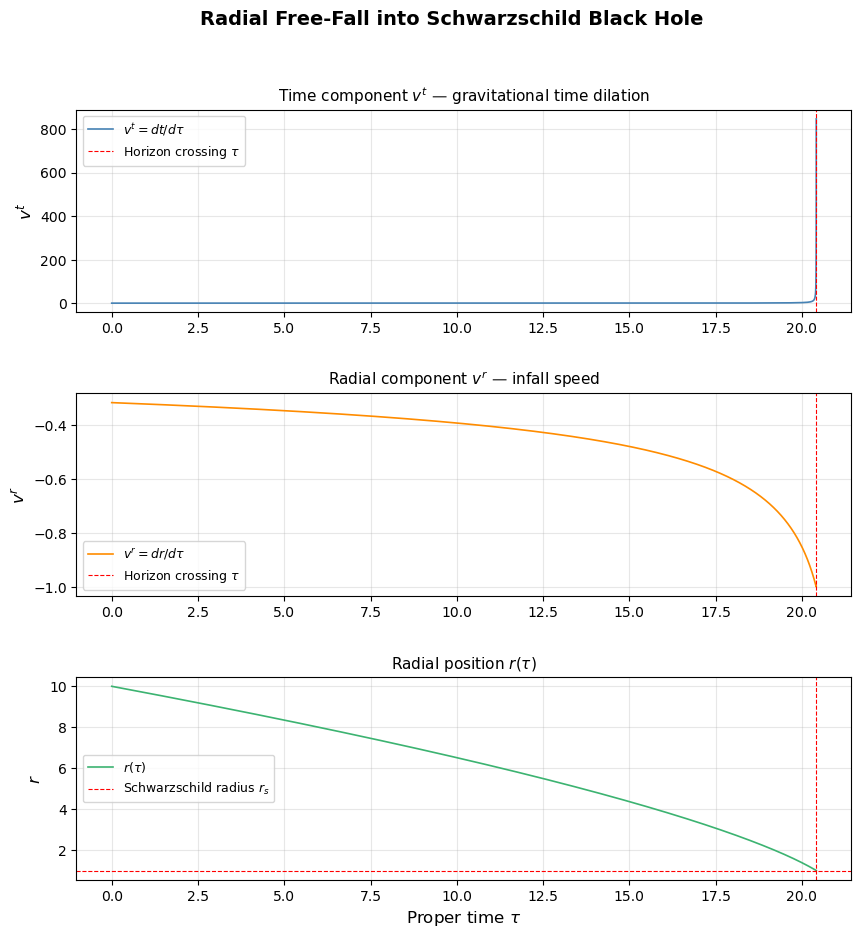

Plot saved to freefall_plot.png


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ---- Load data ----
df = pd.read_csv("freefall.csv")
df = df.dropna()
df = df[df["r"] > 0]
df = df[df["vt"] < 1000]  

tau = df["tau"]
r   = df["r"]
vt  = df["vt"]
vr  = df["vr"]

rs = 1.0  # must match Constants.h

# ---- Figure layout: 3 stacked panels ----
fig = plt.figure(figsize=(10, 10))
fig.suptitle("Radial Free-Fall into Schwarzschild Black Hole", fontsize=14, fontweight="bold")

gs = gridspec.GridSpec(3, 1, hspace=0.4)

# ---- Panel 1: vt over tau ----
ax1 = fig.add_subplot(gs[0])
ax1.plot(tau, vt, color="steelblue", linewidth=1.2, label=r"$v^t = dt/d\tau$")
ax1.axvline(tau.iloc[-1], color="red", linestyle="--", linewidth=0.8, label=r"Horizon crossing $\tau$")
ax1.set_ylabel(r"$v^t$", fontsize=12)
ax1.set_title(r"Time component $v^t$ — gravitational time dilation", fontsize=11)
ax1.legend(fontsize=9)
ax1.set_yscale("linear")
ax1.grid(True, alpha=0.3)

# ---- Panel 2: vr over tau ----
ax2 = fig.add_subplot(gs[1])
ax2.plot(tau, vr, color="darkorange", linewidth=1.2, label=r"$v^r = dr/d\tau$")
ax2.axvline(tau.iloc[-1], color="red", linestyle="--", linewidth=0.8, label=r"Horizon crossing $\tau$")
ax2.set_ylabel(r"$v^r$", fontsize=12)
ax2.set_title(r"Radial component $v^r$ — infall speed", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# ---- Panel 3: r over tau ----
ax3 = fig.add_subplot(gs[2])
ax3.plot(tau, r, color="mediumseagreen", linewidth=1.2, label=r"$r(\tau)$")
ax3.axhline(rs, color="red", linestyle="--", linewidth=0.8, label=r"Schwarzschild radius $r_s$")
ax3.axvline(tau.iloc[-1], color="red", linestyle="--", linewidth=0.8)
ax3.set_xlabel(r"Proper time $\tau$", fontsize=12)
ax3.set_ylabel(r"$r$", fontsize=12)
ax3.set_title(r"Radial position $r(\tau)$", fontsize=11)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.savefig("freefall_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to freefall_plot.png")